# Applied Learning Assignments 1:
1.	Write Python code to filter rows where City_Development_Index > 0.8 and Company_Size is greater than 3.
2.	Use iloc to select the first 10 rows and specific columns like Experience and Education_Level.
3.	Group data by Relevant_Experience and calculate the average City_Development_Index for each group.
4.	Group by Company_Size and count the number of unique entries in Last_New_Job.
5.	Analyze the frequency distribution of Company_Type using value_counts().
6.	Identify numerical columns with missing values and fill them using the mean
7.	Drop rows where more than 50% of data is missing, and document the impacton dataset size.
8.	Query the dataset to extract rows where Experience > 10 and Company_Size == 7.
9.	Create a new feature Experience_Gap by subtracting Last_New_Job from Experience.
10.	Normalize City_Development_Index to a 0–1 scale and explain the benefits of normalization.
11.	Create new column cdi_per and merge it to the original dataframe using pd.merge and analyze the combined insights.

In [1]:
# import libraries

import pandas as pd 
import numpy as np 

In [2]:
#import the dataset

df = pd.read_csv('cleaned_job_change_data.csv')

In [3]:
pd.set_option('display.max_columns', None) #enable viewing all columns in the dataset
df.head() #display the first 5 rows of the dataset

,Enrollee_ID,City,City_Development_Index,Gender,Relevant_Experience,Enrolled_University,Education_Level,Major_Discipline,Experience,Company_Size,Company_Type,Last_New_Job,Training_Hours
0,32403,city_41,0.827,Male,Has relevant experience,Full time course,Graduate,STEM,9,0_9,Unknown,1,21
1,9858,city_103,0.920,Female,Has relevant experience,no_enrollment,Graduate,STEM,5,50_99,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevant experience,no_enrollment,High School,Other,0,50_99,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevant experience,no_enrollment,Masters,STEM,11,10_49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevant experience,no_enrollment,Graduate,STEM,21,10000+,Pvt Ltd,>4,72


In [4]:
df.info() #display the summary of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Enrollee_ID             2129 non-null   int64  
 1   City                    2129 non-null   object 
 2   City_Development_Index  2129 non-null   float64
 3   Gender                  2129 non-null   object 
 4   Relevant_Experience     2129 non-null   object 
 5   Enrolled_University     2129 non-null   object 
 6   Education_Level         2129 non-null   object 
 7   Major_Discipline        2129 non-null   object 
 8   Experience              2129 non-null   int64  
 9   Company_Size            2129 non-null   object 
 10  Company_Type            2129 non-null   object 
 11  Last_New_Job            2129 non-null   object 
 12  Training_Hours          2129 non-null   int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 216.4+ KB


In [5]:
# display the count of unique values in the Company_Size column, including NaN values if present
df['Company_Size'].value_counts(dropna = False) 

Company_Size
50_99        960
100_500      318
10000+       217
10_49        172
0_9          163
1000_4999    143
500_999       88
5000_9999     68
Name: count, dtype: int64

In [6]:
#1. Filter rows where City_Development_Index > 0.8 and Company_Size is greater than 3
# Since Company_Size contains range of values with nothing indicating size less than 3, I will filter only by City_Development_Index > 0.8

filtered_df = df[df['City_Development_Index'] > 0.8]
print(filtered_df) #display thefiltered dataset

      Enrollee_ID      City  City_Development_Index  Gender  \
0           32403   city_41                   0.827    Male   
1            9858  city_103                   0.920  Female   
3           27385   city_13                   0.827    Male   
4           27724  city_103                   0.920    Male   
5             217   city_23                   0.899    Male   
...           ...       ...                     ...     ...   
2124         1289  city_103                   0.920    Male   
2125          195  city_136                   0.897    Male   
2126        31762  city_100                   0.887    Male   
2127         7873  city_102                   0.804    Male   
2128        12215  city_102                   0.804    Male   

          Relevant_Experience Enrolled_University Education_Level  \
0     Has relevant experience    Full time course        Graduate   
1     Has relevant experience       no_enrollment        Graduate   
3     Has relevant experience       

In [7]:
#2. Use iloc to select the first 10 rows and specific columns like Experience and Education_Level

selected_columns = df.iloc[:10, [6,8]]
print(selected_columns) #display the selected columns

  Education_Level  Experience
0        Graduate           9
1        Graduate           5
2     High School           0
3         Masters          11
4        Graduate          21
5         Masters          10
6        Graduate           0
7        Graduate          21
8        Graduate          14
9        Graduate           3


In [8]:
#3. Group data by Relevant_Experience and calculate the average City_Development_Index for each group

grouped_data = df.groupby('Relevant_Experience')['City_Development_Index'].mean()
print(grouped_data)

Relevant_Experience
Has relevant experience    0.831000
No relevant experience     0.809828
Name: City_Development_Index, dtype: float64


In [9]:
#4. Group by Company_Size and count the number of unique entries in Last_New_Job.
grouped_data2 = df.groupby('Company_Size')['Last_New_Job'].nunique()
print(grouped_data2)

Company_Size
0_9          6
10000+       6
1000_4999    6
100_500      6
10_49        6
5000_9999    6
500_999      6
50_99        6
Name: Last_New_Job, dtype: int64


In [10]:
#5. Analyze the frequency distribution of Company_Type using value_counts().

print(df['Company_Type'].value_counts())

Company_Type
Pvt Ltd                1141
Unknown                 634
Public Sector           127
Funded Startup           97
Early Stage Startup      65
NGO                      53
Other                    12
Name: count, dtype: int64


6. Identify numerical columns with missing values and fill them using the mean.
- All numerical columns with missing values have been filled with mean in previous class
7.	Drop rows where more than 50% of data is missing, and document the impact on dataset size.
- There are no columns with more than 50% missing data, even in previous cleaning task

In [11]:

#8.	Query the dataset to extract rows where Experience > 10 and Company_Size == 7.
# Since Company_Size contains range of values with nothing indicating size less than 7, I will extract rows only by Experience > 10

extracted_rows = df.query('Experience > 10')
extracted_rows.head(10) #display the first 10 rows of the extracted dataset

,Enrollee_ID,City,City_Development_Index,Gender,Relevant_Experience,Enrolled_University,Education_Level,Major_Discipline,Experience,Company_Size,Company_Type,Last_New_Job,Training_Hours
3,27385,city_13,0.827,Male,Has relevant experience,no_enrollment,Masters,STEM,11,10_49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevant experience,no_enrollment,Graduate,STEM,21,10000+,Pvt Ltd,>4,72
7,27302,city_160,0.920,Female,Has relevant experience,no_enrollment,Graduate,STEM,21,50_99,Unknown,>4,81
8,12994,city_173,0.878,Male,Has relevant experience,no_enrollment,Graduate,STEM,14,50_99,Unknown,4,2
10,10856,city_103,0.920,Male,Has relevant experience,no_enrollment,Masters,Other,21,50_99,Unknown,>4,196
11,9272,city_90,0.698,Male,Has relevant experience,no_enrollment,Graduate,STEM,20,10_49,Pvt Ltd,2,51
15,24914,city_21,0.624,Male,Has relevant experience,Full time course,Graduate,STEM,13,1000_4999,Pvt Ltd,1,125
24,23570,city_118,0.722,Male,Has relevant experience,no_enrollment,Graduate,STEM,19,100_500,Pvt Ltd,>4,19
25,19139,city_103,0.920,Female,Has relevant experience,Part time course,Graduate,STEM,15,50_99,Public Sector,>4,48
26,9548,city_114,0.926,Male,Has relevant experience,no_enrollment,Masters,STEM,21,50_99,Pvt Ltd,>4,65


In [12]:
# check the unique values in the Last_New_Job column
print(df['Last_New_Job'].unique())

['1' 'never' '>4' '2' '4' '3']


In [13]:
#9.	Create a new feature Experience_Gap by subtracting Last_New_Job from Experience.

df['Last_New_Job'].replace({'never': 0, '>4': 4}) #replace 'never' with 0 and >4 with 4
df['Last_New_Job'] = pd.to_numeric(df['Last_New_Job'], errors='raise') #convert to numeric
df['Experience_Gap'] = df['Experience'] - df['Last_New_Job'] #create the Experience_Gap feature

C:\Users\Abby\AppData\Local\Temp\ipykernel_20336\3948986600.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Last_New_Job'].replace({'never': 0, '>4': 4}, inplace=True) #replace 'never' with 0 and >4 with 4


In [14]:
#10. Normalize City_Development_Index to a 0–1 scale and explain the benefits of normalization.

df['City_Development_Index_Normalized'] = (df['City_Development_Index'] - df['City_Development_Index'].min()) / (df['City_Development_Index'].max() - df['City_Development_Index'].min())

- City_Development_Index was already bounded between 0 and 1 in its raw form, but min-max normalization was still applied to rescale it exactly to [0,1], ensuring consistency with other normalized features and removing any bias in distance-based or gradient-based models caused by minor differences in range.

In [15]:
#11. Create new column cdi_per and merge it to the original dataframe using pd.merge and analyze the combined insights.

# Step 1: build a separate dataframe containing just the new column
cdi_per = pd.DataFrame({
    'cdi_per': df['City_Development_Index'] * 100
}, index=df.index)

# Step 2: merge it into the original df on index 
df = pd.merge(df, cdi_per, left_index=True, right_index=True)

print(df.head())

   Enrollee_ID      City  City_Development_Index  Gender  \
0        32403   city_41                   0.827    Male   
1         9858  city_103                   0.920  Female   
2        31806   city_21                   0.624    Male   
3        27385   city_13                   0.827    Male   
4        27724  city_103                   0.920    Male   

       Relevant_Experience Enrolled_University Education_Level  \
0  Has relevant experience    Full time course        Graduate   
1  Has relevant experience       no_enrollment        Graduate   
2   No relevant experience       no_enrollment     High School   
3  Has relevant experience       no_enrollment         Masters   
4  Has relevant experience       no_enrollment        Graduate   

  Major_Discipline  Experience Company_Size Company_Type  Last_New_Job  \
0             STEM           9          0_9      Unknown             1   
1             STEM           5        50_99      Pvt Ltd             1   
2            Other  

- City_Development_Index_percent was derived from the raw index (not the normalized version) to preserve its interpretability as a percentage of the standard 0–1 development scale, rather than making it relative to this dataset's own min and max.

# Applied Learning Assignments 2:

Steps
1.	Import the required libraries (pandas, matplotlib, numpy).
2.	Load the provided student performance dataset into a pandas DataFrame.
3.	Check for any missing or inconsistent data and handle them accordingly

Bar Chart of Average GPA by Grade Class:
1.	Group the data by GradeClass and calculate the average GPA for each grade class.
2.	Create a bar chart displaying the average GPA for each grade class.
3.	Use a colormap to color the bars based on the GPA values. Choose a color map that reflects the gradient from low to high GPA.
4.	Add annotations to display the exact GPA values on top of the bars.
5.	Make sure the chart has an appropriate title, and labels for the x and y axes.

Scatter Matrix for Study Time, Absences, and GPA:
1.	Create a scatter matrix for the variables StudyTimeWeekly, Absences, and GPA.
2.	Set the diagonal to histograms to show the distribution of each variable.
3.	Use a color that stands out for the points, and add titles and grid lines to improve readability.

Box Plot for Study Time Distribution by Grade Class:
1.	Create a box plot to visualize the distribution of StudyTimeWeekly for each GradeClass.
2.	Ensure each grade class has a corresponding box, and label them properly.
3.	Add a grid, axis labels, and a title to the plot.
4.	Customize the box plot with different colors for each grade class.


In [16]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df2 = pd.read_excel('students_performance_records.xlsx')
print(df2.info()) #display the summary of the dataset
df2.head() #display the first 5 rows of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2390 non-null   object 
 3   Ethnicity          2391 non-null   object 
 4   ParentalEducation  2391 non-null   object 
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   object 
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(9), object(4)
memory usage: 280.4+ KB
None


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,Male,Caucasian,Some College,19.833723,7,1,2,0,0,YES,0,2.929196,2
1,1002,18,Female,Caucasian,High School,15.408756,0,0,1,0,0,No,0,3.042915,1
2,1003,15,Female,Asian,Bachelor's,4.210570,26,0,2,0,0,No,0,0.112602,4
3,1004,17,Male,Caucasian,Bachelor's,10.028829,14,0,3,1,0,No,0,2.054218,3
4,1005,17,Male,Caucasian,Some College,4.672495,17,1,3,0,0,No,0,1.288061,4


In [18]:
df2.isnull().sum() #check for missing values in the dataset

StudentID            0
Age                  0
Gender               2
Ethnicity            1
ParentalEducation    1
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [19]:
df2_null = df2[df2.isnull().any(axis=1)] #create a new dataframe with rows containing missing values
df2_null #display the rows with missing values

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
8,1009,17,NaN,Caucasian,Higher,4.562008,1,0,2,0,1,No,1,2.896819,2
14,1015,18,Male,NaN,High School,11.197811,9,1,2,0,0,No,0,2.396788,3
35,1036,15,NaN,Other,High School,3.415365,23,0,1,0,0,No,0,0.261472,4
49,1050,16,MaleMale,African American,NaN,19.441069,16,0,4,1,0,No,0,2.461047,3


In [20]:
# fill null values in ParentalEducation columnwith mode of the column

df2['ParentalEducation'] = df2['ParentalEducation'].fillna(df2['ParentalEducation'].mode()[0]) 
print(df2['ParentalEducation'].value_counts()) #display the count of unique values in ParentalEducation

ParentalEducation
High School     970
Some College    934
Bachelor's      367
Higher          120
Highest h         1
Name: count, dtype: int64


In [21]:
# replace the wrong spellings in ParentalEducation column for better readability and understanding
df2['ParentalEducation'] = df2['ParentalEducation'].replace({"Highest h": "High School", 
                                                           "Bachelor's": "Bachelor's Degree",
                                                            "Higher" : "Higher Education",})

df2['ParentalEducation'].unique()

array(['Some College', 'High School', "Bachelor's Degree",
       'Higher Education'], dtype=object)

In [22]:
# fill null values in Gender column with mode of the column

df2['Gender'] = df2['Gender'].fillna(df2['Gender'].mode()[0]) 
print(df2['Gender'].value_counts()) #display the count of unique values in Gender

Gender
Male        1223
Female      1167
MaleMale       1
Fema           1
Name: count, dtype: int64


In [23]:
# replace the wrong spellings in Gender column for better readability and understanding
df2['Gender'] = df2['Gender'].replace({"MaleMale": "Male", "Fema": "Female"})

df2['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [24]:
# fill null values in Ethnicity column with mode of the column

df2['Ethnicity'] = df2['Ethnicity'].fillna(df2['Ethnicity'].mode()[0]) 
print(df2['Ethnicity'].value_counts()) #display the count of unique values in Ethnicity

Ethnicity
Caucasian           1207
African American     493
Asian                470
Other                222
Name: count, dtype: int64


In [25]:
# Confirm if there is still missing values in the dataset

df2.isnull().sum() #check for missing values in the dataset  

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

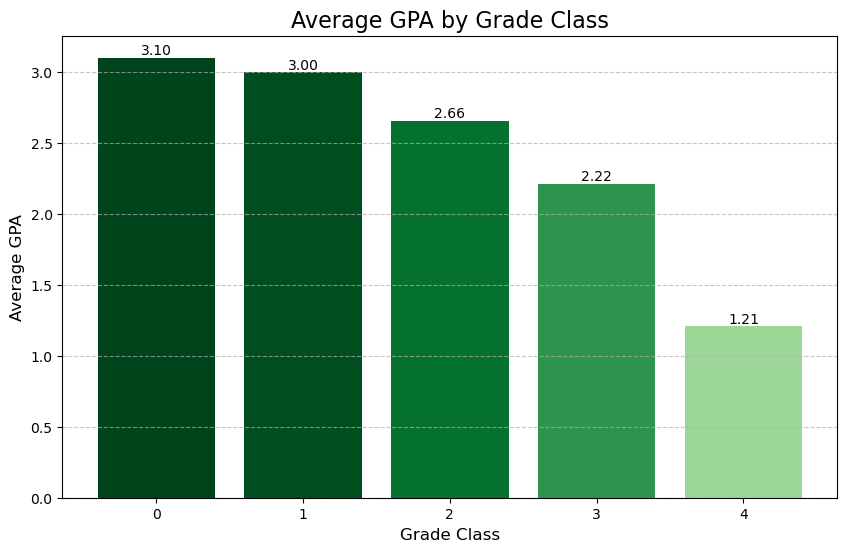

In [26]:
# Create a bar chart displaying the average GPA for each grade class.

# Grouping data by Grade Class and calculating the average GPA
avg_gpa = df2.groupby('GradeClass')['GPA'].mean().reset_index()

# Creating the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(avg_gpa['GradeClass'], avg_gpa['GPA'], color=plt.cm.Greens(avg_gpa['GPA'] / max(avg_gpa['GPA'])))
plt.title('Average GPA by Grade Class', fontsize=16)
plt.xlabel('Grade Class', fontsize=12)
plt.ylabel('Average GPA', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding annotations
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', fontsize=10)

plt.show()

Bar Chart - Average GPA by Grade Class.
This bar chart shows the average GPA for each grade class in the student dataset.

- The x-axis shows the grade class categories.
- The y-axis shows the average GPA value.
- Each bar represents the mean GPA for one grade group.
- The bars are colored using a green gradient, which helps show lower and higher GPA values visually.

This chart is useful for answering questions such as:

Which grade class has the highest average GPA?
Are students in higher grade classes performing better academically?
Is there a noticeable difference in GPA across grade levels?
The annotations above each bar show the exact GPA value, making the chart easier to read without needing to estimate from the axis.

This type of chart is helpful because it gives a quick summary of academic performance across groups. If one grade class has a much higher bar, it suggests that students in that category are achieving stronger academic outcomes on average.

Overall, this chart helps summarize the relationship between grade level and academic performance in a simple and clear way.

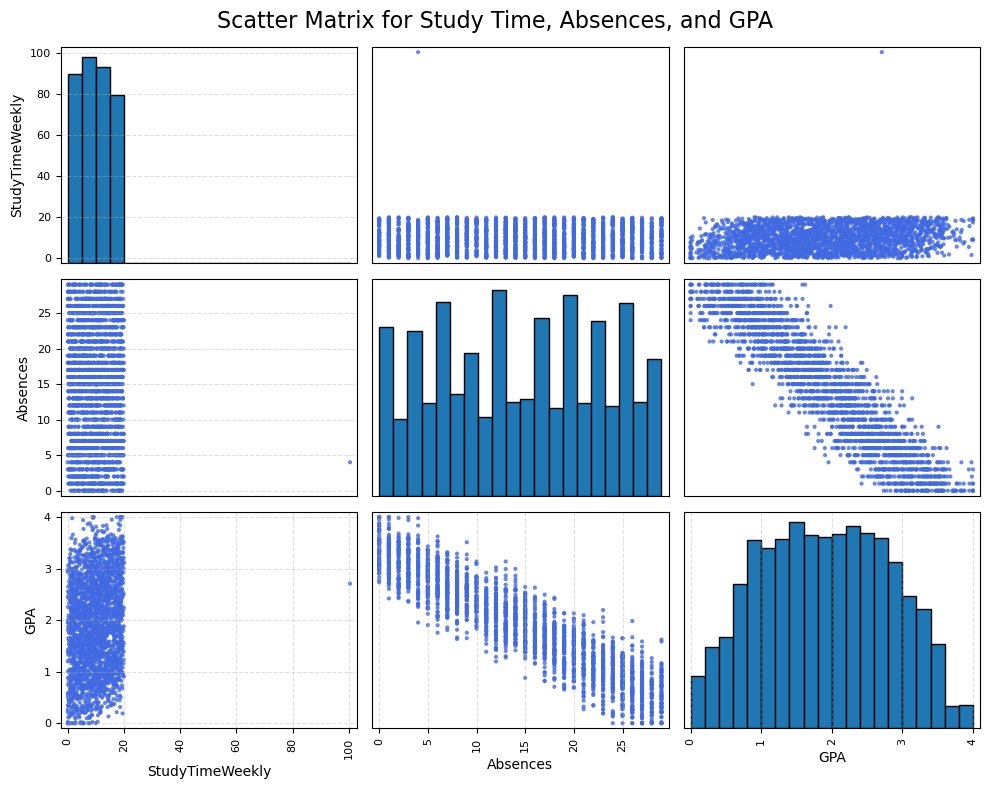

In [27]:
from pandas.plotting import scatter_matrix

cols = ['StudyTimeWeekly', 'Absences', 'GPA']

axes = scatter_matrix(
    df2[cols],
    figsize=(10, 8),
    diagonal='hist',
    alpha=0.8,
    color='royalblue',
    hist_kwds={'bins': 20, 'edgecolor': 'black'}
)

for ax in axes.ravel():
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Scatter Matrix for Study Time, Absences, and GPA', fontsize=16)
plt.tight_layout()
plt.show()



Scatter Matrix - Study Time, Absences, and GPA.
This scatter matrix compares three important variables:

- StudyTimeWeekly
- Absences
- GPA
- The scatter matrix creates a grid of plots where each variable is compared against every other variable.

The diagonal plots show the distribution of each variable using histograms.
The off-diagonal plots show relationships between pairs of variables.
Each point represents one student.

This chart helps answer:

Is more study time associated with higher GPA?
Do students with more absences tend to have lower GPA?
Are absences and study time linked in any visible way?
The diagonal histograms show whether each variable is spread out or clustered around a particular value. 

For example:

A GPA histogram may reveal whether most students are performing in a similar range.
A study time histogram may show whether students mostly study for a few hours or much longer.

The scatterplots help identify patterns such as:

a positive relationship between study time and GPA
a negative relationship between absences and GPA
possible outliers or unusual student profiles
This chart is useful because it gives a quick visual overview of how the selected variables relate to one another before doing deeper analysis.


## Extra
- Use plotly to create a genuinely interactive scatterplot to show the relationship between study time weekly and GPA

In [28]:
# Create a scatter plot to visualize the relationship between StudyTimeWeekly and GPA, with points colored based on GPA.

import plotly.express as px

fig = px.scatter(
    df2,
    x='StudyTimeWeekly',
    y='GPA',
    color='GPA',
    title='GPA vs Study Time Weekly',
    labels={'StudyTimeWeekly': 'Study Time Weekly', 'GPA': 'GPA'}
)

fig.show()

Interactive Scatter Plot - GPA vs. Study Time Weekly.
This Plotly scatter plot shows the relationship between study time and GPA for each student.

- X-axis: StudyTimeWeekly
- Y-axis: GPA
- Point color: GPA value, so higher GPA is shown with stronger colors
It helps answer:

Do students who study more tend to have higher GPA?
Are there students with high GPA despite low study time?
Are there unusual outliers?
This chart is useful because it is interactive, so you can hover over points to inspect individual students more closely.

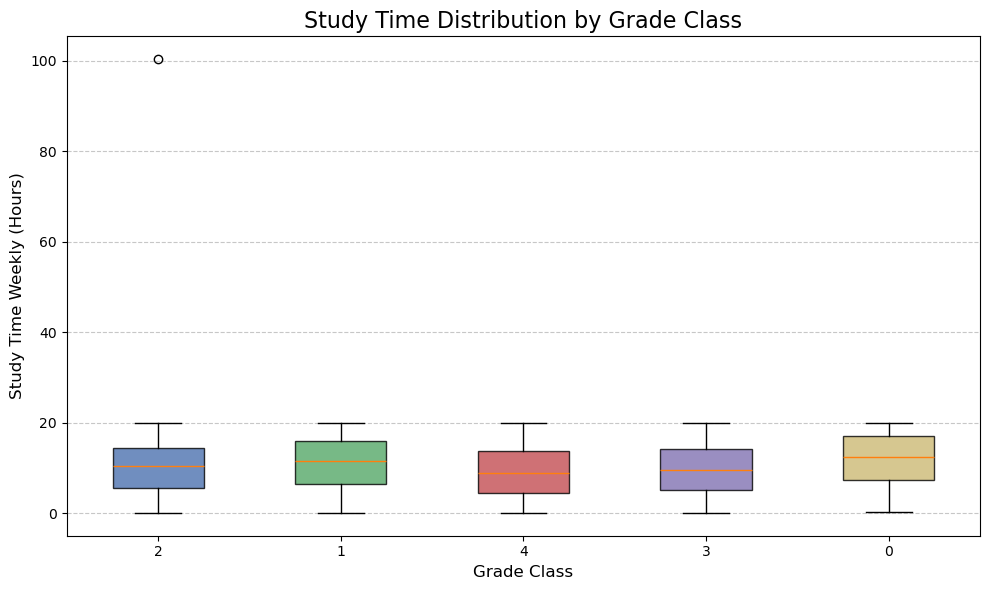

In [29]:
# Box Plot for Study Time Distribution by Grade Class

grade_classes = df2['GradeClass'].dropna().unique()

plt.figure(figsize=(10, 6))

bp = plt.boxplot(
    [df2[df2['GradeClass'] == grade]['StudyTimeWeekly'] for grade in grade_classes],
    patch_artist=True,
    tick_labels=grade_classes,
    widths=0.5
)

# different colors for each grade class
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')

plt.title('Study Time Distribution by Grade Class', fontsize=16)
plt.xlabel('Grade Class', fontsize=12)
plt.ylabel('Study Time Weekly (Hours)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Box Plot - Study Time Distribution by Grade Class.
This box plot shows how study time varies across grade classes.

- The x-axis shows each grade class.
- The y-axis shows study time in hours per week.
- Each box represents the distribution of study time for students in that grade class.

A box plot is helpful because it summarizes the data in a simple form:
- the box contains the middle 50% of values
- the line inside the box is the median
- the whiskers show the spread of the rest of the data
- points outside the whiskers may be outliers

This chart helps answer:

Which grade class studies the most?
Is there a lot of variation in study time within each class?
Are some groups more consistent than others?

For example:

A higher median in one grade class suggests students in that group study more on average.
A wider box means study time varies more within that class.
A narrow box means students in that class have more similar study habits.
This chart is especially useful because it shows both the center and spread of the data, not just the average. That makes it better for understanding whether differences between grade classes are meaningful or just due to variation.

Overall, this chart helps compare the study patterns of different grade groups and shows whether academic performance may be related to how much time students spend studying.

# Applied Learning Assignments 3:
Objectives:
Recreate and analyze the provided Seaborn plots using the dataset. Ensure proper styling, labels, and visual clarity. 

KDE Plot - Age vs. Heart Attack Outcome
1.	Modify the KDE plot to include shade=True, adjust bw_adjust for better smoothing, and use a different palette for better contrast.
2.	Add a vertical line indicating the median age of patients who had a heart attack.
3.	Title: "Age Distribution by Heart Attack Outcome"
4.	X-axis Label: "Age (Years)"
5.	Y-axis Label: "Density"

Heatmap - Correlation of Risk Factors
1.	Generate a correlation matrix heatmap.
2.	Adjust annotations, color map, and mask half the heatmap for better readability.
3.	Ensure the most correlated features are highlighted distinctly.
4.	Title: "Correlation of Heart Attack Risk Factors"
5.	X-axis Label & Y-axis Label: Feature Names

Boxplot - Cholesterol Levels by Heart Attack Outcome
1.	Modify the boxplot to include hue="Gender" to compare cholesterol levels across males and females.
2.	Adjust outlier visibility and tweak whiskers to better visualize cholesterol distribution.
3.	Title: "Cholesterol Levels Distribution by Heart Attack Outcome and Gender"
4.	X-axis Label: "Heart Attack Outcome (0 = No, 1 = Yes)"
5.	Y-axis Label: "Cholesterol Level (mg/dL)"

Pairplot - Multiple Risk Factors & Outcome
1.	Create a pairplot including Cholesterol_Level, Obesity_Index, LDL_Level, and Heart_Attack_Outcome.
2.	Adjust markers, increase plot size, and set diag_kind="kde" for better insight.
3.	Title: "Pairwise Comparison of Key Risk Factors"
4.	X-axis Label & Y-axis Label: Feature Names

Violin Plot - Blood Pressure by Heart Attack Outcome
1.	Create a violin plot to compare Blood_Pressure_Systolic and Blood_Pressure_Diastolic across heart attack outcomes.
2.	Adjust split=True to better visualize distributions.
3.	Title: "Blood Pressure Distribution by Heart Attack Outcome"
4.	X-axis Label: "Heart Attack Outcome (0 = No, 1 = Yes)"
5.	Y-axis Label: "Blood Pressure (mmHg)"

Countplot - Smoking and Heart Attack Outcome
1.	Generate a countplot to visualize the number of smokers and non-smokers across heart attack outcomes.
2.	Use a hue="Gender" parameter to compare distributions by gender.
3.	Title: "Smoking Status and Heart Attack Outcome by Gender"
4.	X-axis Label: "Smoking Status (Yes/No)"
5.  Y-axis Label: "Count

In [30]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df3 = pd.read_csv('heart_attack_south_africa.csv')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Patient_ID                    100000 non-null  int64  
 1   Age                           100000 non-null  int64  
 2   Gender                        100000 non-null  object 
 3   Cholesterol_Level             100000 non-null  int64  
 4   Blood_Pressure_Systolic       100000 non-null  int64  
 5   Blood_Pressure_Diastolic      100000 non-null  int64  
 6   Smoking_Status                100000 non-null  object 
 7   Alcohol_Intake                100000 non-null  object 
 8   Physical_Activity             100000 non-null  object 
 9   Obesity_Index                 100000 non-null  float64
 10  Diabetes_Status               100000 non-null  object 
 11  Family_History_Heart_Disease  100000 non-null  object 
 12  Diet_Quality                  100000 non-null

In [32]:
df3.head(3)

,Patient_ID,Age,Gender,Cholesterol_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Smoking_Status,Alcohol_Intake,Physical_Activity,Obesity_Index,Diabetes_Status,Family_History_Heart_Disease,Diet_Quality,Stress_Level,Heart_Attack_History,Medication_Usage,Triglycerides_Level,LDL_Level,HDL_Level,Heart_Attack_Outcome
0,1,76,Female,156,94,79,No,High,Sedentary,35.2,No,No,Good,High,No,No,264,141,65,0
1,2,39,Female,160,185,88,No,Low,Sedentary,21.3,No,No,Average,Medium,No,Yes,150,81,42,0
2,3,85,Male,254,173,113,Yes,Moderate,Highly Active,32.0,Yes,No,Good,Low,No,No,220,124,70,1


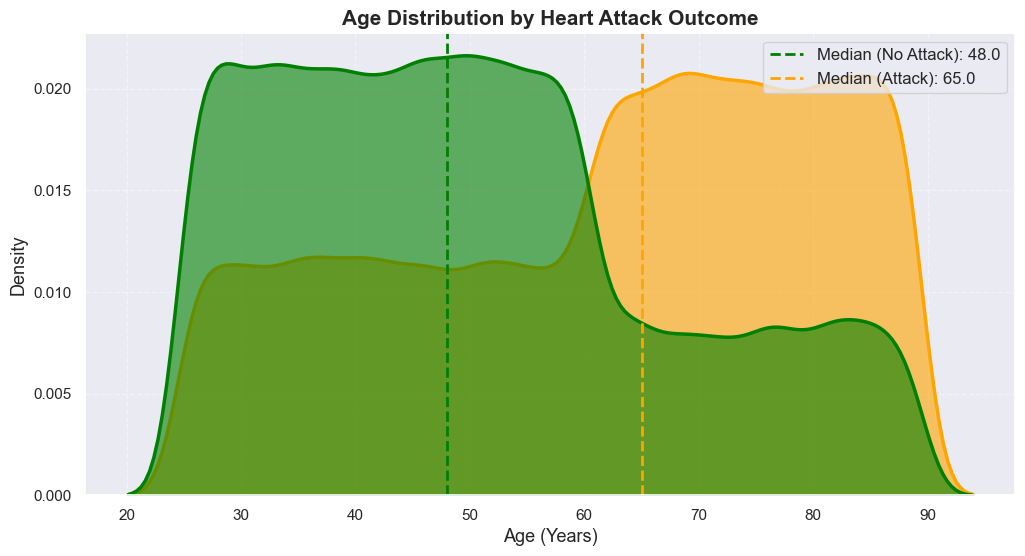

In [33]:
# KDE Plot - Age vs. Heart Attack Outcome

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="dark")

# KDE Plot with enhanced customization
ax = sns.kdeplot(
    data=df3, x="Age", hue="Heart_Attack_Outcome",
    fill=True, common_norm=False,
    palette=["green", "orange"], alpha=0.6, linewidth=2.5,
    bw_adjust=0.8,  # Adjust bandwidth for smoother distribution
)

# Overlay a vertical line at the median age for each outcome group
median_no_attack = df3[df3["Heart_Attack_Outcome"] == 0]["Age"].median()
median_attack = df3[df3["Heart_Attack_Outcome"] == 1]["Age"].median()

plt.axvline(median_no_attack, color="green", linestyle="--", linewidth=2, label=f"Median (No Attack): {median_no_attack}")
plt.axvline(median_attack, color="orange", linestyle="--", linewidth=2, label=f"Median (Attack): {median_attack}")

# Title and Labels
plt.title("Age Distribution by Heart Attack Outcome", fontsize=15,
          fontweight="bold")
plt.xlabel("Age (Years)", fontsize=13)
plt.ylabel("Density", fontsize=13)

# Custom Legend
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc="upper right", fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle="--", alpha=0.4)

# Show plot
plt.show()

## KDE Plot - Age vs. Heart Attack Outcome

This KDE (Kernel Density Estimate) plot shows how the age distribution differs between patients who had a heart attack and those who did not.

- The x-axis represents age in years.
- The y-axis represents density, which tells us how concentrated the data is at different ages.
- The two colors represent the two outcome groups:
  - green = no heart attack
  - orange = heart attack
- The shaded curves make it easier to compare the spread and peak age ranges for each group.

This chart helps answer questions such as:
- Are patients with heart attacks older on average?
- Is the age distribution narrower or wider in one group?
- Are there clear age ranges where the risk is higher?

The vertical lines show the median age for each group, which is a useful summary statistic because it identifies the middle value in the distribution without being affected by extreme values.

Overall, this plot suggests whether age is an important factor in heart attack risk and how the risk varies across age groups.

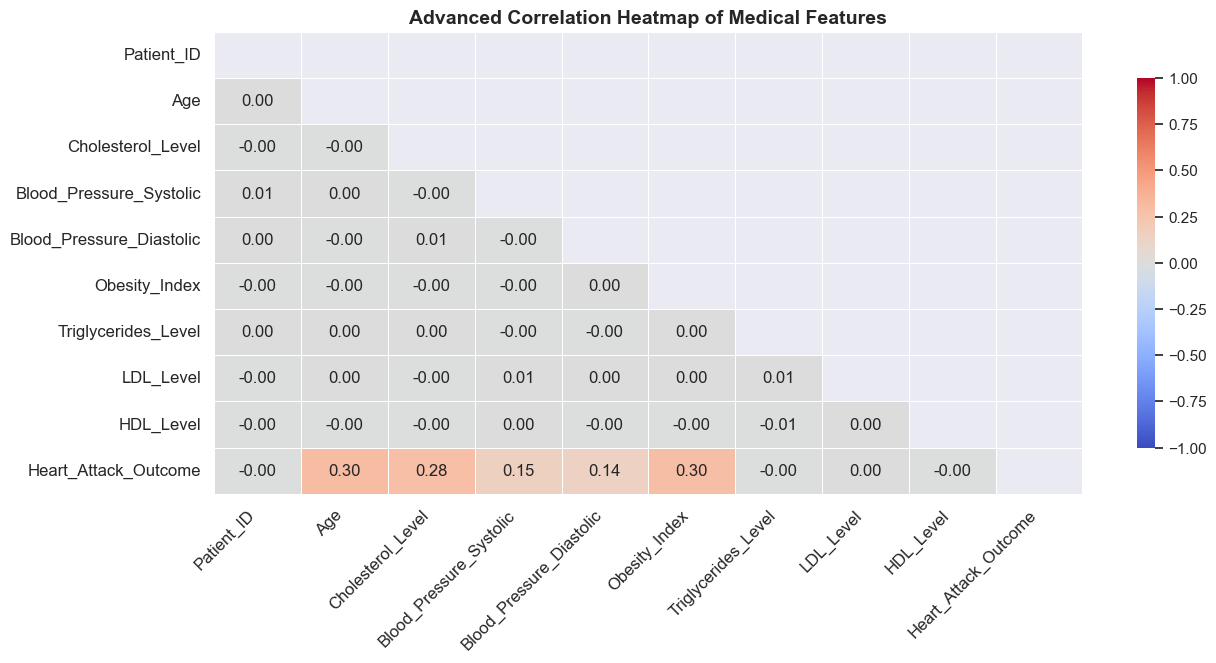

In [34]:
# Heatmap - Correlation of Risk Factors

# Compute correlation matrix
correlation_matrix = df3.corr(numeric_only=True)

# Mask the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the figure
plt.figure(figsize=(14, 6))

# Generate a heatmap with advanced settings
sns.heatmap(
    correlation_matrix, mask=mask,
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.7,
    vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}
)

# Title and display
plt.title("Advanced Correlation Heatmap of Medical Features", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## Heatmap - Correlation of Risk Factors

This heatmap displays the correlation matrix for several medical and lifestyle variables in the dataset.

- A correlation tells us how strongly two variables move together.
- Values are between -1 and 1:
  - near +1 means strong positive relationship
  - near -1 means strong negative relationship
  - near 0 means weak or no relationship
- The color intensity shows the strength and direction of the relationship.

This plot is useful for identifying which risk factors tend to change together. For example:
- If cholesterol and LDL are highly positively correlated, it suggests that as one increases, the other also tends to increase.
- If obesity and blood pressure are strongly related, this may indicate a common pattern in risk factors.

The upper triangle is masked so the chart is easier to read without repeating the same information twice.
The annotations in each cell show the actual correlation value, making the heatmap easier to interpret.

This chart helps identify the strongest relationships between features before building predictive models or drawing deeper conclusions.

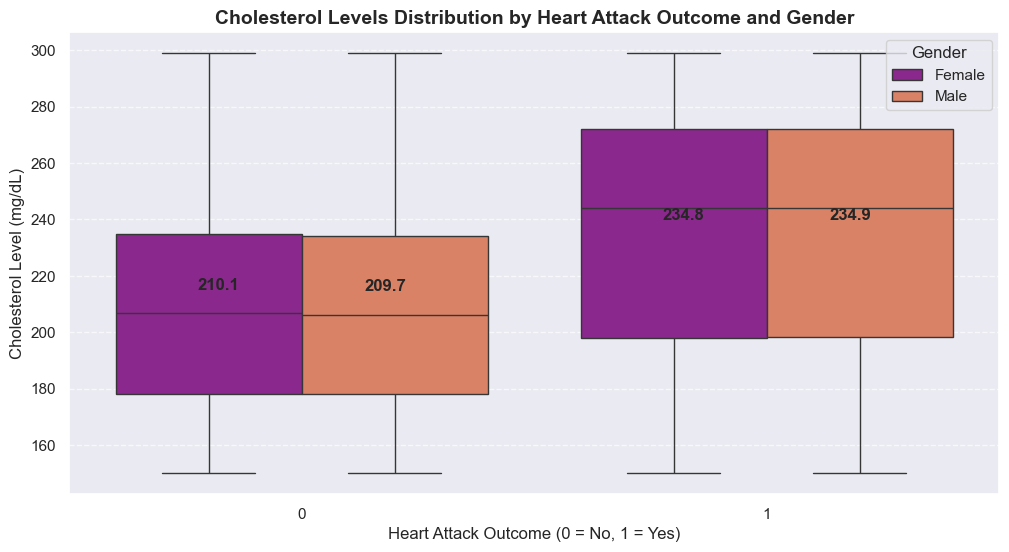

In [35]:
# Boxplot - Cholesterol Levels by Heart Attack Outcome


plt.figure(figsize=(12, 6))

# Create the boxplot
ax = sns.boxplot(x="Heart_Attack_Outcome", y="Cholesterol_Level", hue="Gender",
    data=df3, palette="plasma", showfliers=True, fliersize=1, whis=1.5
)

# Calculate means by outcome and gender
group_means = df3.groupby(["Heart_Attack_Outcome", "Gender"])["Cholesterol_Level"].mean().reset_index()

# Create custom x-offsets for each gender
outcome_order = sorted(df3["Heart_Attack_Outcome"].unique())
gender_order = list(df3["Gender"].dropna().unique())

for outcome in outcome_order:
    for gender in gender_order:
        mean_val = group_means[(group_means["Heart_Attack_Outcome"] == outcome) &
            (group_means["Gender"] == gender)]["Cholesterol_Level"].values[0]

        x_pos = outcome_order.index(outcome)
        offset = 0.18 if gender == gender_order[1] else -0.18
        ax.text(x_pos + offset, mean_val + 5, f"{mean_val:.1f}", horizontalalignment="center", 
                fontweight="bold")


plt.title("Cholesterol Levels Distribution by Heart Attack Outcome and Gender", fontsize=14, 
          fontweight="bold")
plt.xlabel("Heart Attack Outcome (0 = No, 1 = Yes)")
plt.ylabel("Cholesterol Level (mg/dL)")
plt.legend(title="Gender", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## Boxplot - Cholesterol Levels by Heart Attack Outcome and Gender

This boxplot compares cholesterol levels across heart attack outcomes and gender groups.

- The x-axis shows heart attack outcome:
  - 0 = No Heart Attack
  - 1 = Heart Attack
- The y-axis shows cholesterol level in mg/dL.
- The color split by gender shows differences between male and female patients.

A boxplot summarizes the distribution of a variable:
- the box represents the middle 50% of data
- the line inside the box is the median
- the whiskers show the spread of the remaining data
- points outside the whiskers may be outliers

This chart helps answer:
- Do patients who had heart attacks have higher cholesterol levels?
- Are cholesterol patterns different for men and women?
- Are there outliers or extreme cholesterol values in one group?

By comparing both outcome and gender, the chart gives a more detailed picture of how cholesterol may vary among subgroups.

<Figure size 1400x800 with 0 Axes>

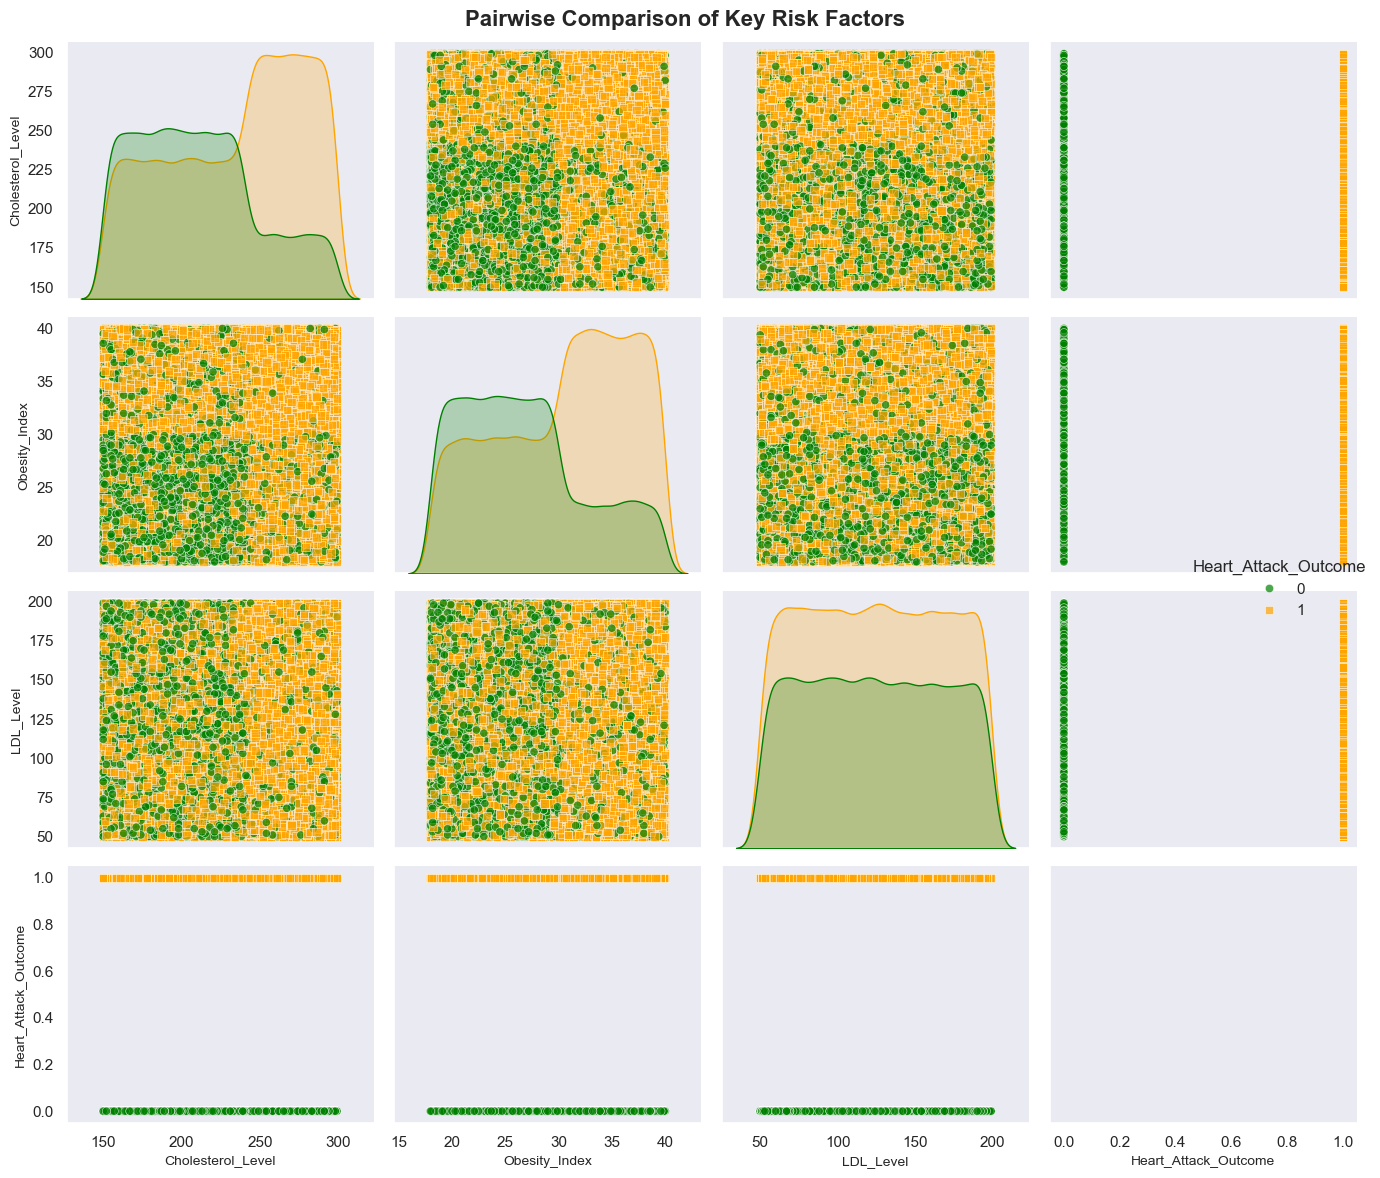

In [36]:
# Pairplot - Multiple Risk Factors & Outcome (Option 1)

# Set up the figure
plt.figure(figsize=(14, 8))

# Create a pairplot with the selected variables
pairplot = sns.pairplot(
    df3,
    vars=["Cholesterol_Level", "Obesity_Index", "LDL_Level", "Heart_Attack_Outcome"],
    hue="Heart_Attack_Outcome",
    palette={0: "green", 1: "orange"},
    markers=["o", "s"],
    diag_kind="kde",
    plot_kws={"alpha": 0.7},
    height=3
)

# Add title
pairplot.figure.suptitle("Pairwise Comparison of Key Risk Factors", fontsize=16, fontweight="bold")

# Set axis labels for the figure
for ax in pairplot.axes.flat:
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=10)
        ax.set_ylabel(ax.get_ylabel(), fontsize=10)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

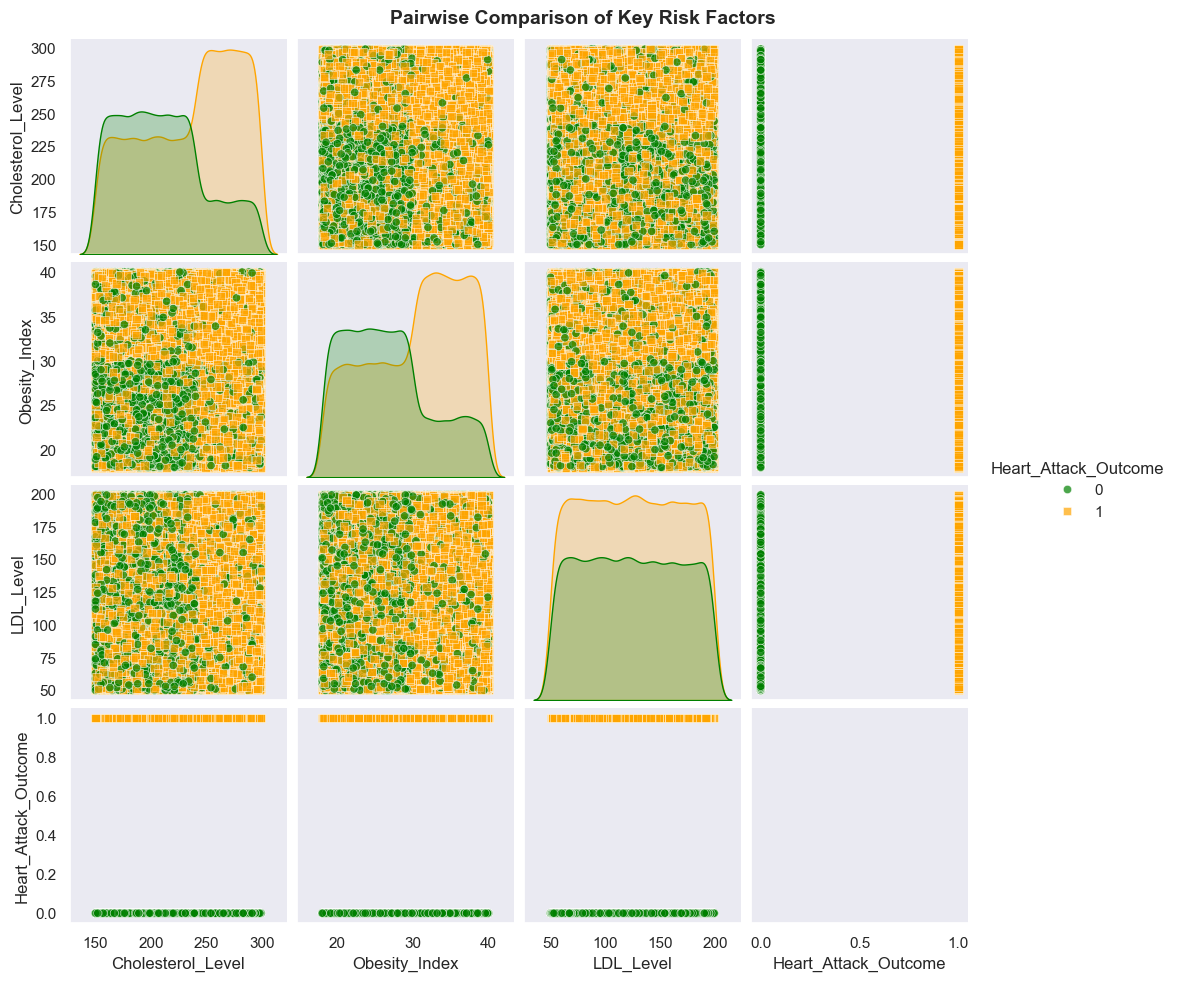

In [37]:
# # Pairplot - Multiple Risk Factors & Outcome (Option 2)


# Set up the figure
plt.figure(figsize=(14, 6))

# Create a pairplot with the selected variables and additional styling
pairplot = sns.pairplot(
    df3,
    vars=["Cholesterol_Level", "Obesity_Index", "LDL_Level", "Heart_Attack_Outcome"],
    hue="Heart_Attack_Outcome",
    palette={0: "green", 1: "orange"},  # Explicit mapping for better readability
    markers=["o", "s"],  # Different markers for classes
    diag_kind="kde",  # Use KDE plots for diagonal
    plot_kws={"alpha": 0.7}  # Add transparency for better visualization
)

# Add a title with spacing
plt.subplots_adjust(top=0.95)
pairplot.figure.suptitle("Pairwise Comparison of Key Risk Factors", fontsize=14, fontweight='bold')

plt.show()

# Notes on pairplot charts
First block = more customized and cleaner
Second block = simpler and shorter

- Difference 1: figure sizing and layout

First block: height=3 controls the height of each subplot
pairplot.figure.suptitle(...) sets the title at the top of the whole pairplot
for ax in pairplot.axes.flat: loops through each subplot and adjusts the axis labels
plt.tight_layout() makes spacing cleaner before showing

Second block:
plt.figure(figsize=(14, 6)) sets a figure size before creating the pairplot
plt.subplots_adjust(top=0.95) adjusts spacing only at the top
It does not loop through each axis to change label properties
It is simpler, but less customized

- Difference 2: title size and spacing

First block title:
Second block title:
So the first one makes the title a bit larger.

- Difference 3: label styling

First block:
This explicitly sets the font size of the x and y labels inside each subplot.

Second block does not do this.

- Difference 4: overall layout control

First block:
This is a more general layout adjustment after all elements are added.

Second block:
This only adjusts the space at the top for the title

## Pairplot - Multiple Risk Factors & Outcome

This pairplot visualizes relationships between several key health variables:
- Cholesterol_Level
- Obesity_Index
- LDL_Level
- Heart_Attack_Outcome

A pairplot creates a grid of scatterplots, where each variable is compared against every other variable.

- The diagonal plots show the distribution of each variable.
- The off-diagonal plots show how two variables relate to each other.
- Different colors represent the two outcome groups:
  - No Heart Attack
  - Heart Attack

This chart helps identify patterns such as:
- whether higher LDL levels are associated with heart attack risk
- whether cholesterol and obesity move together
- whether one variable separates the two outcome groups more clearly than the others

Using `diag_kind="kde"` makes the diagonal plots smoother and more informative by showing distributions as density curves rather than just simple histograms.

Overall, this plot is a quick way to visually inspect multiple relationships in one figure.

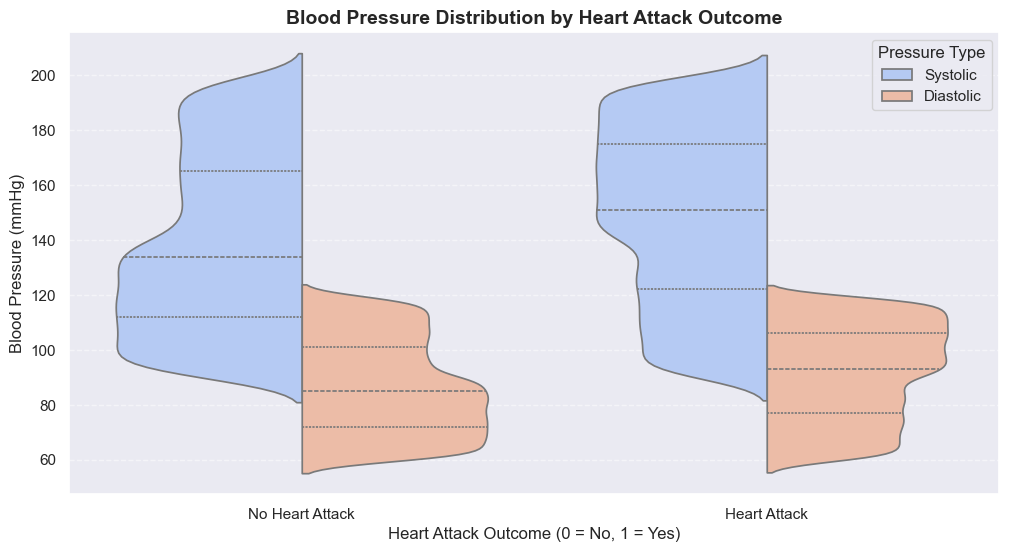

In [38]:
# Violin Plot - Blood Pressure by Heart Attack Outcome

# Reshape the data so systolic and diastolic are in one numeric column
bp_long = df3.melt(
    id_vars="Heart_Attack_Outcome",
    value_vars=["Blood_Pressure_Systolic", "Blood_Pressure_Diastolic"],
    var_name="Blood_Pressure_Type",
    value_name="Blood_Pressure"
)

# Rename the outcome labels for readability
bp_long["Heart_Attack_Outcome"] = bp_long["Heart_Attack_Outcome"].map({
    0: "No Heart Attack",
    1: "Heart Attack"
})

# Clean up the pressure type labels
bp_long["Blood_Pressure_Type"] = bp_long["Blood_Pressure_Type"].replace({
    "Blood_Pressure_Systolic": "Systolic",
    "Blood_Pressure_Diastolic": "Diastolic"
})

plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    data=bp_long,
    x="Heart_Attack_Outcome",
    y="Blood_Pressure",
    hue="Blood_Pressure_Type",
    split=True,
    palette="coolwarm",
    inner="quartile",
    bw_adjust=1.2
)

plt.title("Blood Pressure Distribution by Heart Attack Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Heart Attack Outcome (0 = No, 1 = Yes)")
plt.ylabel("Blood Pressure (mmHg)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Pressure Type")
plt.show()

## Violin Plot - Blood Pressure by Heart Attack Outcome

This violin plot compares blood pressure distributions for patients with and without heart attacks.

- The x-axis shows heart attack outcome:
  - No Heart Attack
  - Heart Attack
- The y-axis shows blood pressure in mmHg
- The plot includes both systolic and diastolic blood pressure values, separated by color

A violin plot combines a boxplot and a density curve:
- the width of the violin shows how common different blood pressure values are
- the wider sections indicate more observations around that value
- the narrower sections indicate fewer observations

This chart helps answer:
- Do heart attack patients tend to have higher systolic or diastolic blood pressure?
- Is the pressure distribution wider or narrower in one group?
- Are there important differences between the two pressure types?

Because the plot is split by blood pressure type, it makes it easier to compare how systolic and diastolic readings differ across the two outcome groups.

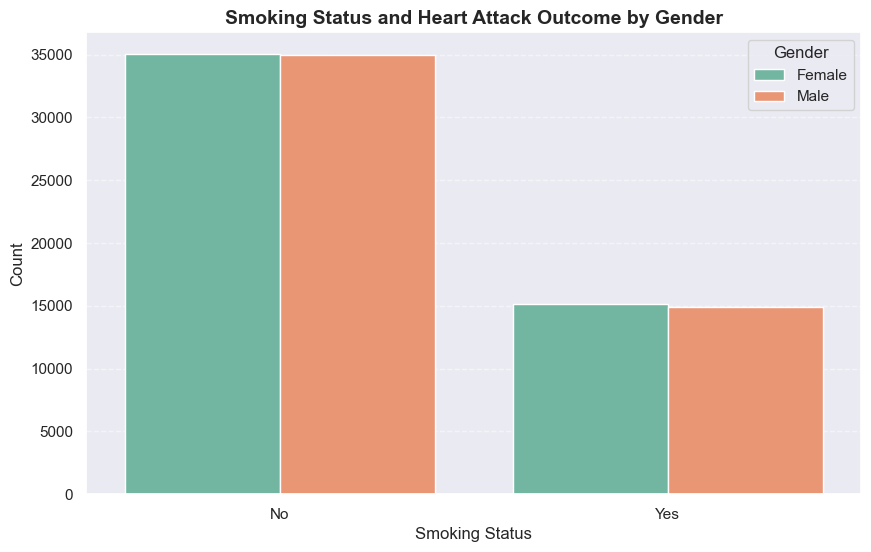

In [39]:
# Countplot - Smoking and Heart Attack Outcome

# Make sure the smoking column is readable
if "Smoking_Status" in df3.columns:
    smoke_col = "Smoking_Status"
elif "Smoking" in df3.columns:
    smoke_col = "Smoking"
else:
    raise ValueError("No smoking column found. Check the column name in df3.")

# Convert numeric smoking values to Yes/No if needed
if df3[smoke_col].dtype.kind in "biufc":
    df3[smoke_col] = df3[smoke_col].map({1: "Yes", 0: "No"})

# Make heart attack labels readable (optional, for clarity)
if "Heart_Attack_Outcome" in df3.columns:
    df3["Heart_Attack_Outcome"] = df3["Heart_Attack_Outcome"].map({
        0: "No Heart Attack",
        1: "Heart Attack"
    })

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df3,
    x=smoke_col,
    hue="Gender",
    palette="Set2"
)

plt.title("Smoking Status and Heart Attack Outcome by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Countplot - Smoking and Heart Attack Outcome

This countplot shows how many people are smokers or non-smokers, and compares the counts across gender groups.

- The x-axis shows smoking status:
  - Yes
  - No
- The y-axis shows the number of patients in each category
- The colors represent gender
- This helps us compare male and female counts within each smoking group

The chart is useful for answering questions such as:
- Are more people smokers or non-smokers in this dataset?
- Does smoking status differ by gender?
- Are there more smokers among patients who had heart attacks?

This plot is a simple frequency chart: it counts how many observations fall into each category. It is especially helpful when working with categorical variables like smoking status and gender.

By adding the gender split, we can see whether the smoking pattern changes across male and female patients.

Deeptech Week 5 Assignment done by Aishat Omolabake Ajibola